In [4]:
import pandas as pd
import rasterio
import matplotlib.colors as mcolors
from numpy.ma.core import masked
from scipy.stats import binned_statistic_2d
from model_comparison_functions import process_all_dates
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
#from mcs_shared import ALL_FLIGHT_DATES, load_isnobal_depth, load_als_depth

In [2]:
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs\dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs\dates", 2)

In [5]:
RESOLUTION = 100
ASPECT_BIN_COUNT = 9
ELEVATION_BIN_COUNT = 11

# Generate data
## DEM from original resolution
```bash
gdal raster reproject --resolution 10,10 --bbox 601558.000,4862467.500,609431.500,4870872.500 --resampling cubic --overwrite --co COMPRESS=LZW --co PREDICTOR=2 --co TILED=YES --input ../orig/MCS_REFDEM_32611.tif --output MCS_REFDEM_32611_10m.tif
```
## DEM for flight
```bash
gdal raster reproject --overwrite --bbox 601558.000,4862467.500,609431.500,4870872.500 MCS_REFDEM_32611_10m.tif pattern_flight_area.vrt
```
## Aspect
```bash
gdal raster aspect --overwrite MCS_flight_area_dem.vrt MCS_flight_area_aspect.tif
```

## Filepaths for basin

In [160]:
dem_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/static/reproject/DEM.tif"
aspect_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/static/reproject/aspect.tif"

In [267]:
iSnobal = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task1/rasters/iSnobal_basin_clip.tif"
iSnobal_t2 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task2/rasters/iSnobal_basin_clip.tif"
SM = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task1/rasters/SnowModel_basin_clip.tif"
SM_t2 = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task2/rasters/SnowModel_basin_clip.tif"
TI = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task1/rasters/HMS_TI_basin_clip.tif"
EB = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates/20230405/outputs/task1/rasters/HMS_EB_basin_clip.tif"


In [283]:
def raster_prep(reference_fp, dem_fp, aspect_fp):
    
    with rasterio.open(reference_fp) as ref:
        ref_shape = (ref.height, ref.width)
        ref_transform = ref.transform
        ref_crs = ref.crs
    
    # --- Reproject elevation ---
    elevation_aligned = np.empty(ref_shape, dtype=np.float32)
    
    with rasterio.open(dem_fp) as dem:
        reproject(
            source=dem.read(1),
            destination=elevation_aligned,
            src_transform=dem.transform,
            src_crs=dem.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    
    # --- Reproject aspect ---
    aspect_aligned = np.empty(ref_shape, dtype=np.float32)
    
    with rasterio.open(aspect_fp) as asp:
        reproject(
            source=asp.read(1),
            destination=aspect_aligned,
            src_transform=asp.transform,
            src_crs=asp.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.nearest  # important for categorical-ish data
        )


    elev_min = np.floor(np.nanmin(elevation_aligned[elevation_aligned > 0]) / 100) * 100
    elev_max = np.ceil(np.nanmax(elevation_aligned) / 100) * 100
    elev_bins = np.linspace(elev_min, elev_max, ELEVATION_BIN_COUNT)
    aspect_bins = np.linspace(0, 360, ASPECT_BIN_COUNT)
    
    return elevation_aligned, aspect_aligned, elev_min, elev_max, aspect_bins, elev_bins

def load_flight(reference_fp,  dem_fp, aspect_fp, source_fp, title_String):
    
    elevation_aligned, aspect_aligned, elev_min, elev_max, aspect_bins, elev_bins = raster_prep(reference_fp, dem_fp, aspect_fp)
    
    with rasterio.open(reference_fp) as ref:
        ref_data = ref.read(1, masked = True)
        dst_transform = ref.transform
        dst_crs = ref.crs
        ref_bounds = ref.bounds

    with rasterio.open(source_fp) as src:
        dst_data = src.read(1,masked = True)
        src_transform = src.transform
        reprojected_model = np.empty(ref_data.shape, dtype=np.float32)

        reproject(
            source=dst_data,
            destination=reprojected_model,
            src_transform=src_transform,
            src_crs="EPSG:32611",
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    #valid = (~np.isnan(dst_data)) & (~np.isnan(ref_data))
    combined_mask = (ref_data.data == -9999) | (reprojected_model == -9999)
    ref_masked = np.ma.array(ref_data, mask=combined_mask)
    src = np.ma.array(reprojected_model, mask=combined_mask)
    diff_masked = ref_masked - src
    # Using the refined indexing from your last snippet
    data = diff_masked.compressed()     
    elevation = elevation_aligned[~combined_mask] 
    aspect = aspect_aligned[~combined_mask]

    statistic, x_edge, y_edge, _bin_number = binned_statistic_2d(
        aspect,
        elevation,
        data,
        statistic='mean',
        bins=[aspect_bins, elev_bins]
    )
    return diff_masked, statistic, ref_bounds, title_String, elevation_aligned, aspect_aligned, elev_min, elev_max, aspect_bins, elev_bins

def plot_flight(reference_fp, dem_fp, aspect_fp, source_fp, title_String):
    diff_masked, data, ref_bounds, title_String, elevation_aligned, aspect_aligned, elev_min, elev_max, aspect_bins, elev_bins = load_flight(reference_fp, dem_fp, aspect_fp, source_fp, title_String)    
    fig = plt.figure(figsize=(12,8))
    fig.suptitle(title_String, fontsize=16, fontweight='bold')
    ax1 = fig.add_subplot(121, projection='polar')
    ax1.set_theta_zero_location('N')  # North at top
    ax1.set_theta_direction(-1)       # Clockwise
    
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    cmap = plt.cm.coolwarm_r

    # Make a hole in the middle for easier reading of higher values
    inner_val = elev_max + 100 
    # Put the highest in the middle
    ax1.set_rorigin(inner_val)

    # Sections for each ring
    width_deg = 360 / (ASPECT_BIN_COUNT - 1)
    width = np.deg2rad(width_deg)
    theta_centers = np.deg2rad(np.arange(0, 360, width_deg))
    
    for i, t in enumerate(theta_centers):
        for j in range(ELEVATION_BIN_COUNT - 1):
            val = data[i, j]
            color = 'whitesmoke' if np.isnan(val) else cmap(norm(val))
            
            ax1.bar(
                x=t,
                height=elev_bins[j+1] - elev_bins[j], 
                bottom=elev_bins[j], 
                width=width,
                color=color,
                edgecolor='none'
            )
    
    ax1.grid(True, axis='both', color='black', linewidth=1.5, zorder=3)

    ax1.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax1.set_xticklabels(
        ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], 
        fontsize=12, 
        fontweight='bold', 
        color='black'
    )
    
    ax1.set_ylim(inner_val, elev_min)
    ax1.set_yticks(elev_bins)
    ax1.set_rlabel_position(10)
    x_labels = np.empty_like(elev_bins, dtype=object)
    x_labels[0] = f"{int(elev_min)} m"
    ax1.set_yticklabels(
        x_labels, 
        fontsize=12, 
        color='black',
    )

    # Center "dot"
    ax1.plot(0, inner_val, 'o', color='white', markersize=32, zorder=5)
    
    # Scale Bar
    scale_ax = fig.add_axes([0.04, 0.35, 0.02, 0.3])
    scale_ax.set_ylim(elev_max, elev_min)
    scale_ax.set_yticks(elev_bins)
    scale_ax.set_yticklabels([f"{int(v)}" for v in elev_bins], fontsize=12)
    scale_ax.set_xticks([])
    scale_ax.grid(True, axis='y', color='black', linestyle='-', linewidth=0.8)
    scale_ax.set_axisbelow(False)
    scale_ax.set_ylabel('Elevation (m)', fontweight='bold', fontsize=12)
    
    ax2 = fig.add_subplot(122)
    #build raster from differenced array for plotting
    ax2.imshow(
    diff_masked, 
    extent=[ref_bounds.left, ref_bounds.right, ref_bounds.bottom, ref_bounds.top], 
    cmap=cmap, 
    norm=norm
    )
    ax.set_title("Differenced Snow Depth", fontsize=16)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=[ax1, ax2], pad=0.1, shrink=0.8, extend='both', orientation='horizontal')
    cbar.set_label('Difference (m)', fontsize=14)
    plt.show()

BoundingBox(left=572400.0, bottom=4831500.0, right=608800.0, top=4878000.0)


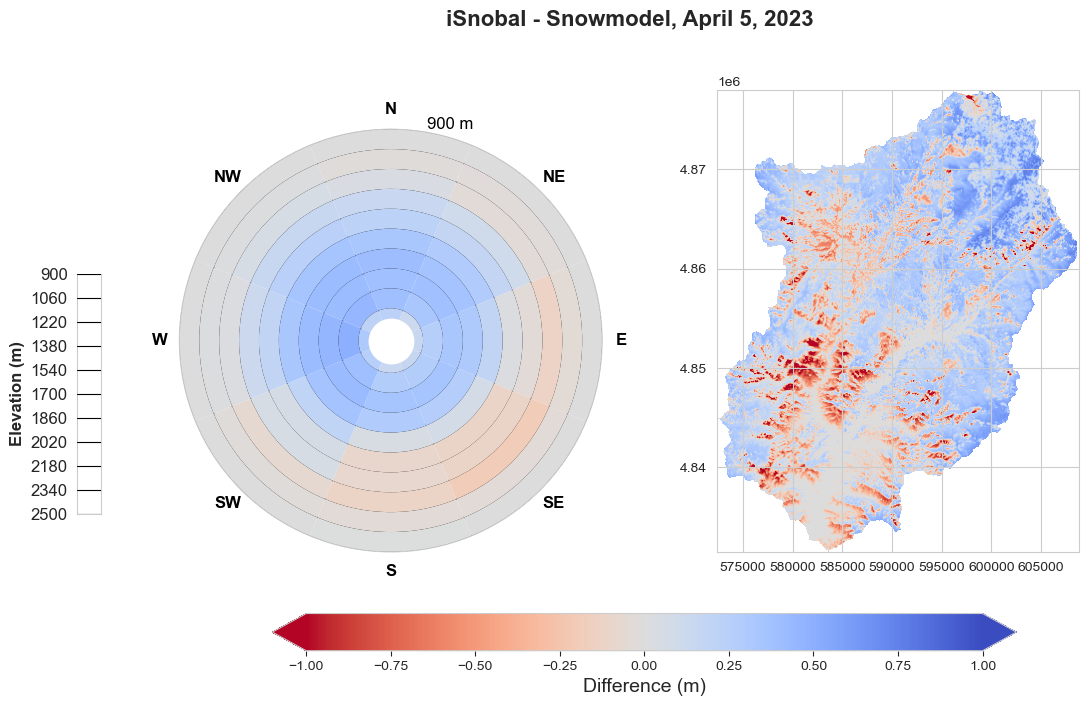

BoundingBox(left=572400.0, bottom=4831500.0, right=608800.0, top=4878000.0)


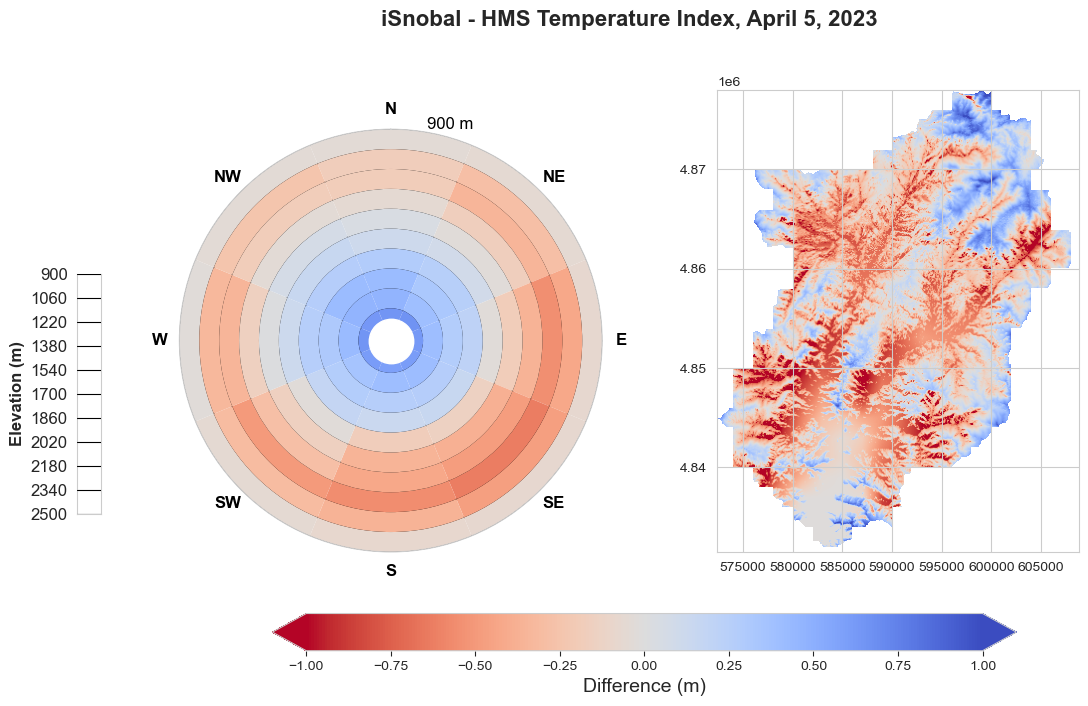

BoundingBox(left=572400.0, bottom=4831500.0, right=608800.0, top=4878000.0)


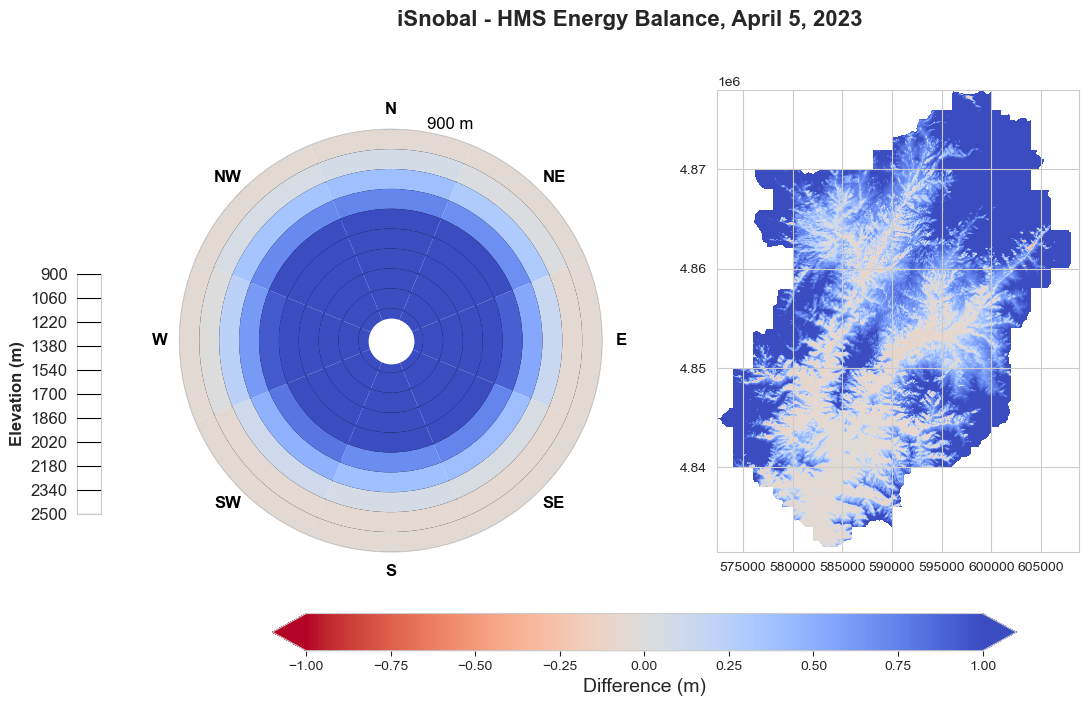

In [285]:
dem_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/static/reproject/DEM.tif"
aspect_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/static/reproject/aspect.tif"
plot_flight(iSnobal, dem_fp, aspect_fp, SM, "iSnobal - Snowmodel, April 5, 2023")
plot_flight(iSnobal, dem_fp, aspect_fp, TI, "iSnobal - HMS Temperature Index, April 5, 2023")
plot_flight(iSnobal, dem_fp, aspect_fp, EB, "iSnobal - HMS Energy Balance, April 5, 2023")


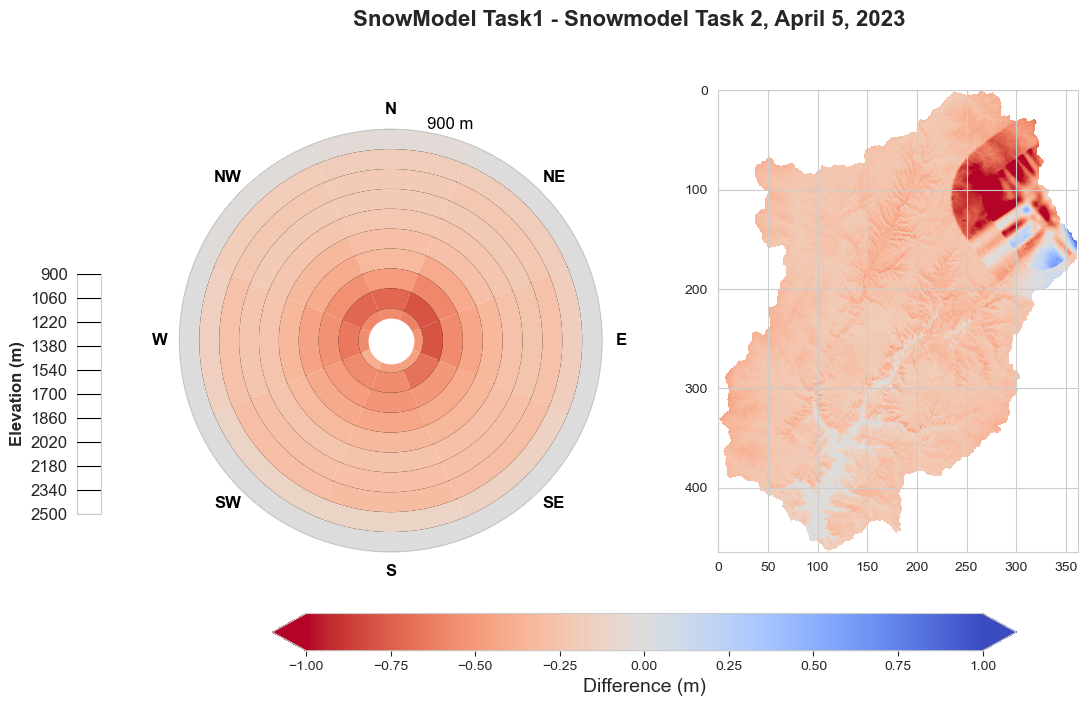

In [273]:
plot_flight(SM, dem_fp, aspect_fp, SM_t2, "SnowModel Task1 - Snowmodel Task 2, April 5, 2023")


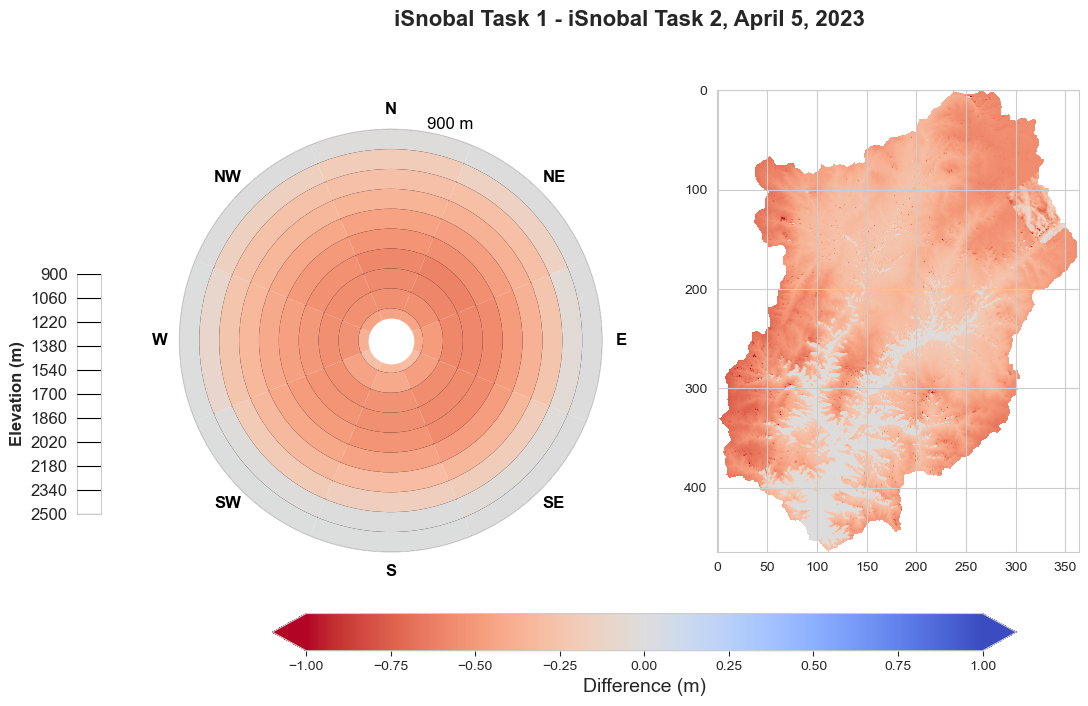

In [254]:
plot_flight(iSnobal_t2, iSnobal, "iSnobal Task 1 - iSnobal Task 2, April 5, 2023")


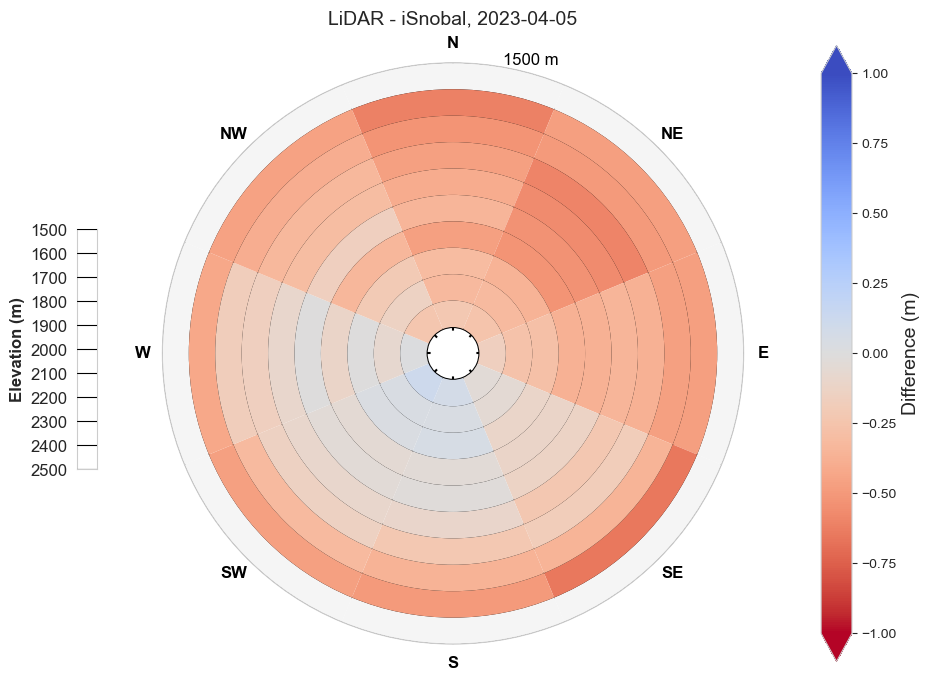

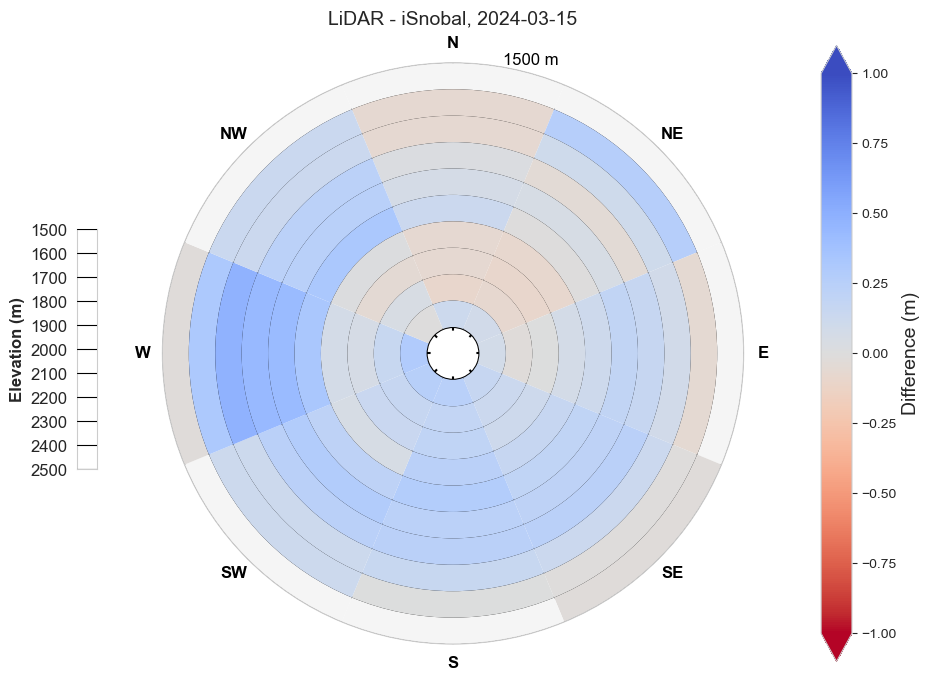

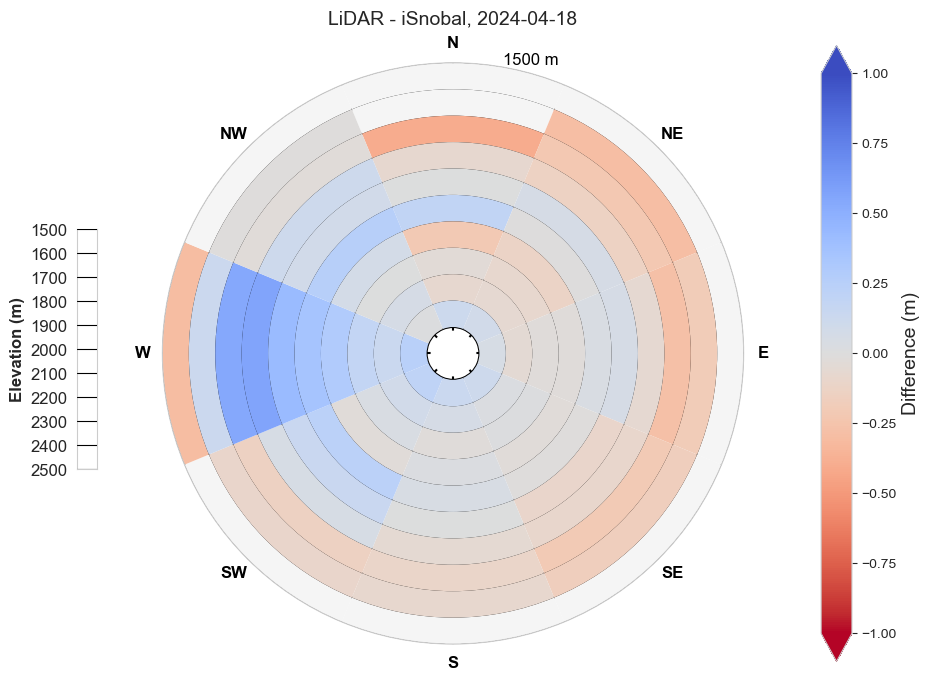

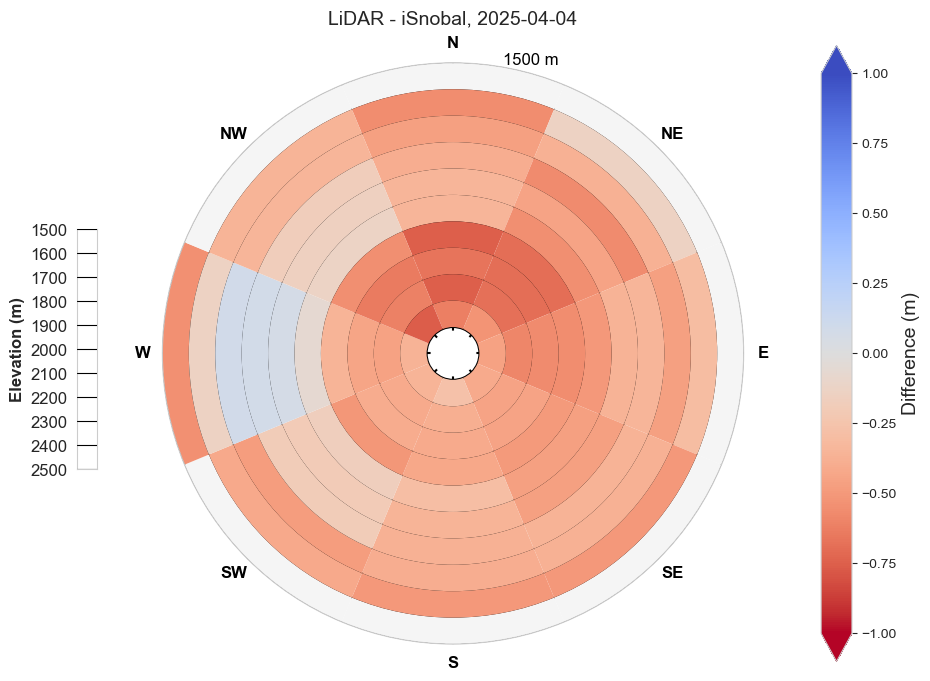

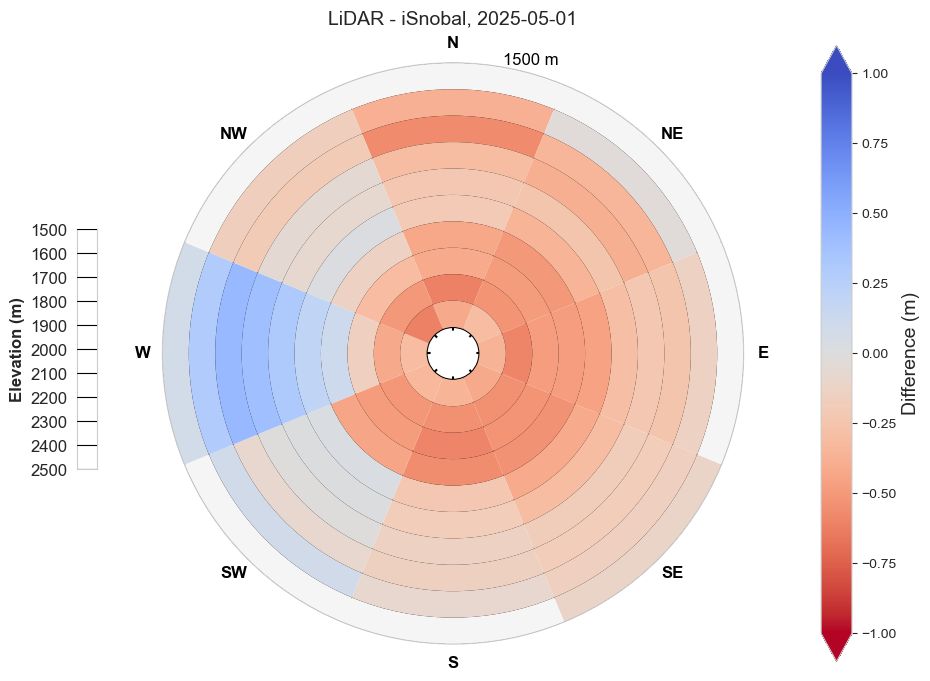

In [154]:
for date, raster_path in task1_iSno_diff.items():
    with rasterio.open(raster_path) as src:
        data = src.read(1)
    mask = ~np.isnan(data)
    aspect_vals = aspect_2d[mask]
    elev_vals = elevation_2d[mask]
    data_vals = data[mask]
    statistic, x_edge, y_edge, _ = binned_statistic_2d(
        aspect_vals,
        elev_vals,
        data_vals,
        statistic='mean',
        bins=[aspect_bins, elev_bins]
    )
    
    
    data = statistic
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    ax.set_theta_zero_location('N')  # North at top
    ax.set_theta_direction(-1)       # Clockwise
    
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    cmap = plt.cm.coolwarm_r
    
    # Make a hole in the middle for easier reading of higher values
    inner_val = elev_max + 100 
    # Put the highest in the middle
    ax.set_rorigin(inner_val)
    
    # Sections for each ring
    width_deg = 360 / (ASPECT_BIN_COUNT - 1)
    width = np.deg2rad(width_deg)
    theta_centers = np.deg2rad(np.arange(0, 360, width_deg))
    
    for i, t in enumerate(theta_centers):
        for j in range(ELEVATION_BIN_COUNT - 1):
            val = data[i, j]
            color = 'whitesmoke' if np.isnan(val) else cmap(norm(val))
            
            ax.bar(
                x=t,
                height=elev_bins[j+1] - elev_bins[j], 
                bottom=elev_bins[j], 
                width=width,
                color=color,
                edgecolor='none'
            )
    
    ax.grid(True, axis='both', color='black', linewidth=1.5, zorder=3)
    
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(
        ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], 
        fontsize=12, 
        fontweight='bold', 
        color='black'
    )
    
    ax.set_ylim(inner_val, elev_min)
    ax.set_yticks(elev_bins)
    ax.set_rlabel_position(10)
    x_labels = np.empty_like(elev_bins, dtype=object)
    x_labels[0] = f"{int(elev_min)} m"
    ax.set_yticklabels(
        x_labels, 
        fontsize=12, 
        color='black',
    )
    
    # Center "dot"
    ax.plot(0, inner_val, 'o', color='white', markersize=32, zorder=5)
    
    # Scale Bar
    scale_ax = fig.add_axes([0.04, 0.35, 0.02, 0.3])
    scale_ax.set_ylim(elev_max, elev_min)
    scale_ax.set_yticks(elev_bins)
    scale_ax.set_yticklabels([f"{int(v)}" for v in elev_bins], fontsize=12)
    scale_ax.set_xticks([])
    scale_ax.grid(True, axis='y', color='black', linestyle='-', linewidth=0.8)
    scale_ax.set_axisbelow(False)
    scale_ax.set_ylabel('Elevation (m)', fontweight='bold', fontsize=12)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.1, extend='both')
    cbar.set_label('Difference (m)', fontsize=14)
    
    ax.set_title(pd.to_datetime(date).strftime("LiDAR - iSnobal, %Y-%m-%d"), va='bottom', fontsize=14)
    
    plt.show()

In [ ]:
[plot_flight(date) for date in task1_SM_diff]

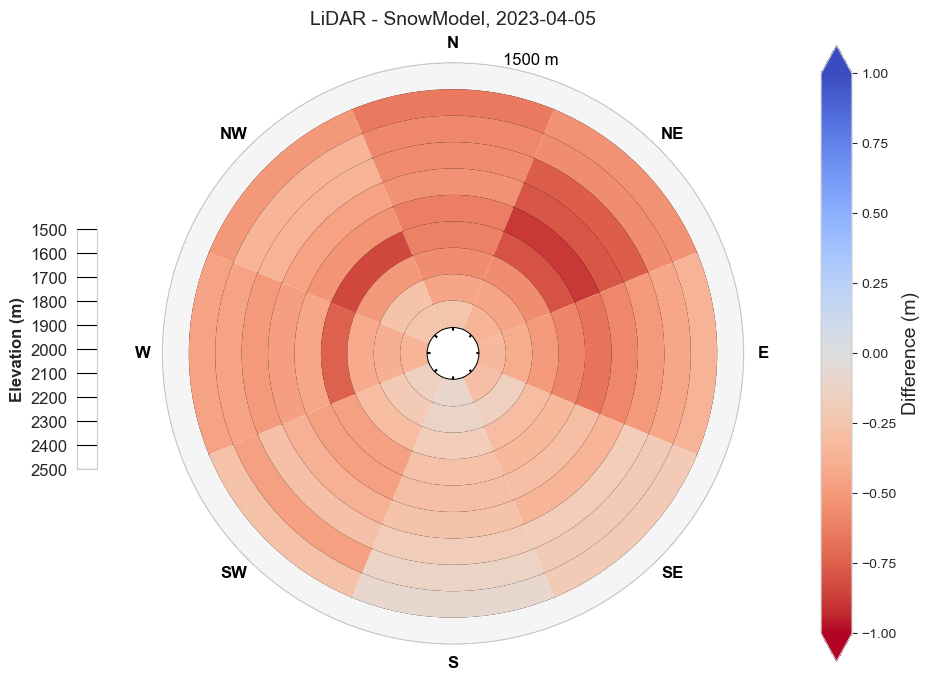

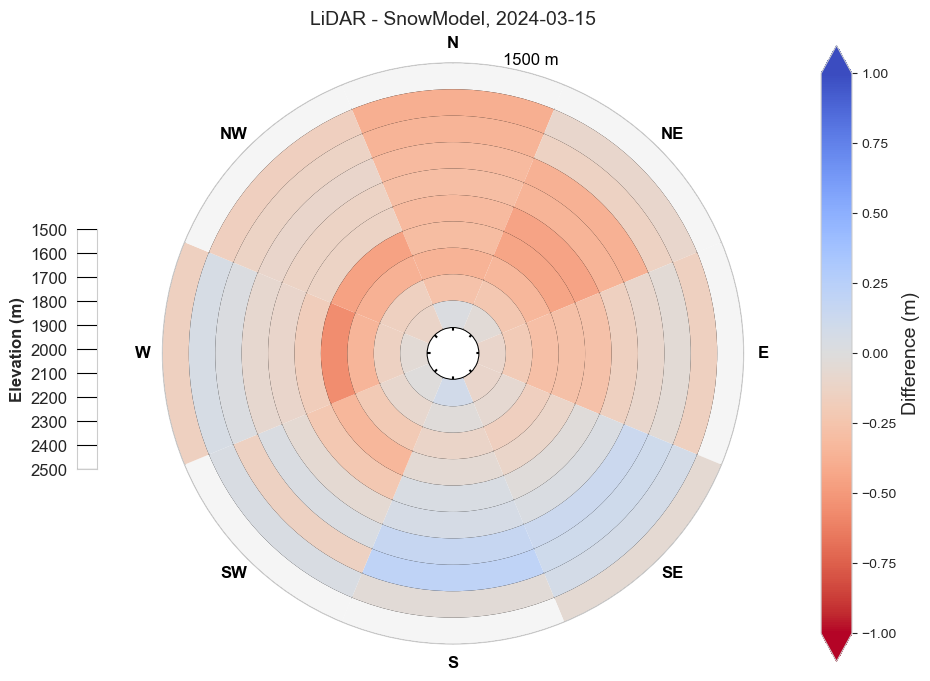

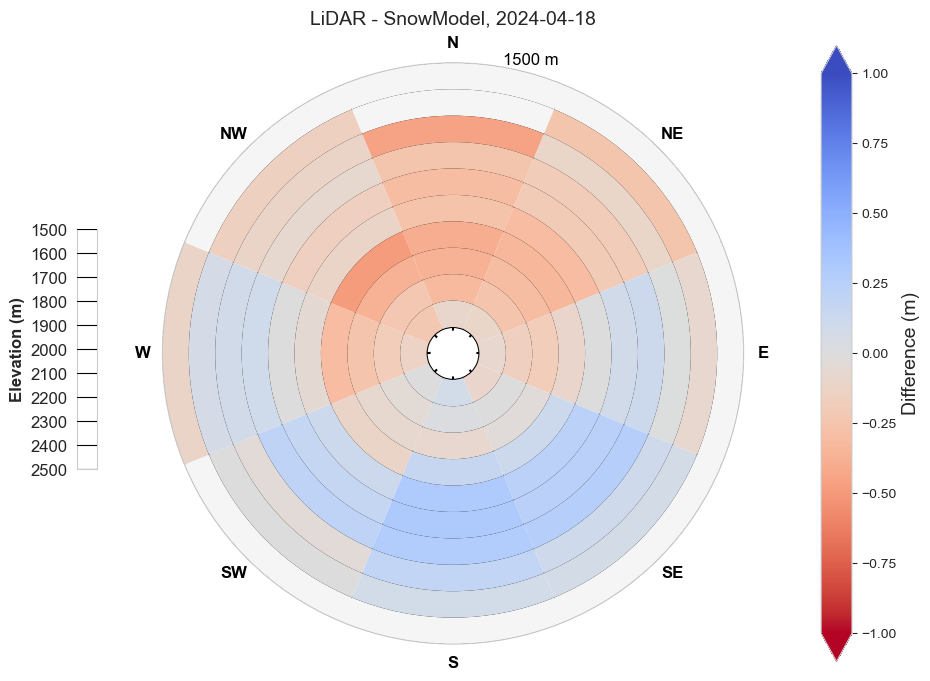

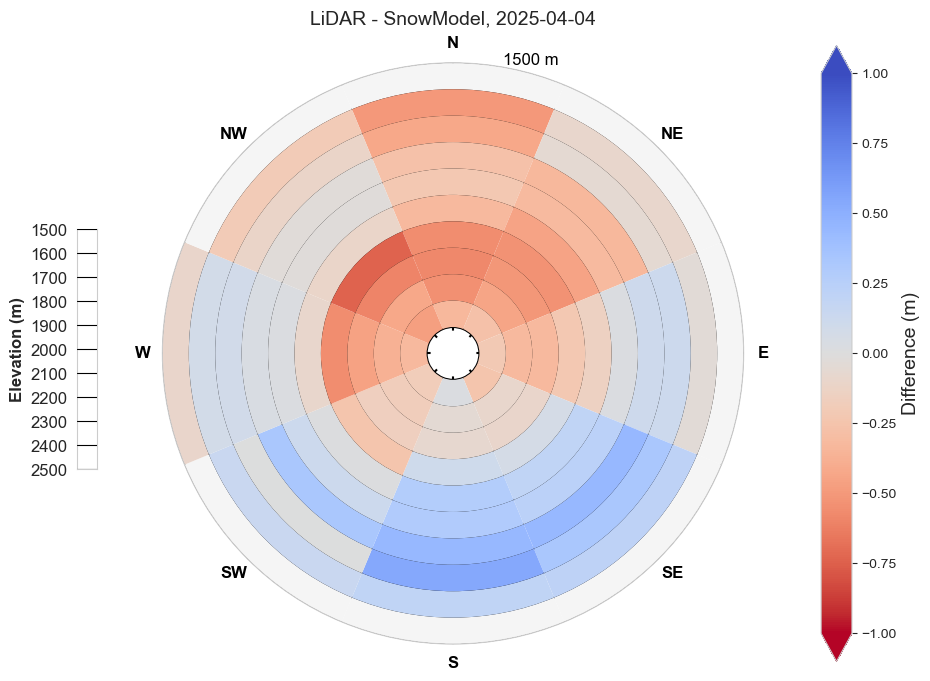

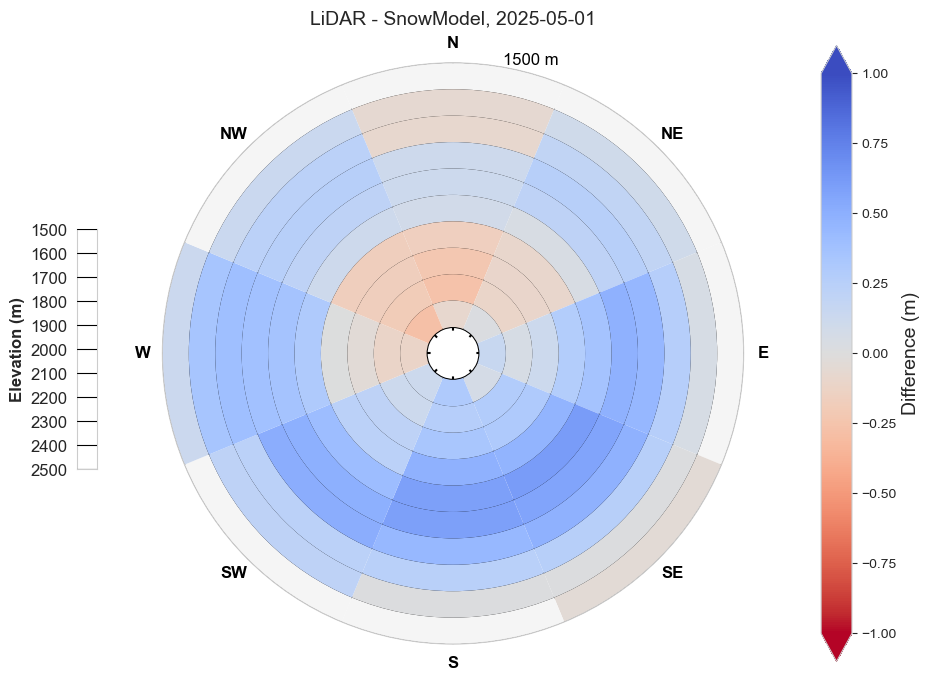

In [10]:
for date, raster_path in task1_SM_diff.items():
    with rasterio.open(raster_path) as src:
        data = src.read(1)
    mask = ~np.isnan(data)
    aspect_vals = aspect_2d[mask]
    elev_vals = elevation_2d[mask]
    data_vals = data[mask]
    statistic, x_edge, y_edge, _ = binned_statistic_2d(
        aspect_vals,
        elev_vals,
        data_vals,
        statistic='mean',
        bins=[aspect_bins, elev_bins]
    )
    
    
    data = statistic
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    ax.set_theta_zero_location('N')  # North at top
    ax.set_theta_direction(-1)       # Clockwise
    
    norm = mcolors.Normalize(vmin=-1, vmax=1)
    cmap = plt.cm.coolwarm_r
    
    # Make a hole in the middle for easier reading of higher values
    inner_val = elev_max + 100 
    # Put the highest in the middle
    ax.set_rorigin(inner_val)
    
    # Sections for each ring
    width_deg = 360 / (ASPECT_BIN_COUNT - 1)
    width = np.deg2rad(width_deg)
    theta_centers = np.deg2rad(np.arange(0, 360, width_deg))
    
    for i, t in enumerate(theta_centers):
        for j in range(ELEVATION_BIN_COUNT - 1):
            val = data[i, j]
            color = 'whitesmoke' if np.isnan(val) else cmap(norm(val))
            
            ax.bar(
                x=t,
                height=elev_bins[j+1] - elev_bins[j], 
                bottom=elev_bins[j], 
                width=width,
                color=color,
                edgecolor='none'
            )
    
    ax.grid(True, axis='both', color='black', linewidth=1.5, zorder=3)
    
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(
        ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], 
        fontsize=12, 
        fontweight='bold', 
        color='black'
    )
    
    ax.set_ylim(inner_val, elev_min)
    ax.set_yticks(elev_bins)
    ax.set_rlabel_position(10)
    x_labels = np.empty_like(elev_bins, dtype=object)
    x_labels[0] = f"{int(elev_min)} m"
    ax.set_yticklabels(
        x_labels, 
        fontsize=12, 
        color='black',
    )
    
    # Center "dot"
    ax.plot(0, inner_val, 'o', color='white', markersize=32, zorder=5)
    
    # Scale Bar
    scale_ax = fig.add_axes([0.04, 0.35, 0.02, 0.3])
    scale_ax.set_ylim(elev_max, elev_min)
    scale_ax.set_yticks(elev_bins)
    scale_ax.set_yticklabels([f"{int(v)}" for v in elev_bins], fontsize=12)
    scale_ax.set_xticks([])
    scale_ax.grid(True, axis='y', color='black', linestyle='-', linewidth=0.8)
    scale_ax.set_axisbelow(False)
    scale_ax.set_ylabel('Elevation (m)', fontweight='bold', fontsize=12)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.1, extend='both')
    cbar.set_label('Difference (m)', fontsize=14)
    
    ax.set_title(pd.to_datetime(date).strftime("LiDAR - SnowModel, %Y-%m-%d"), va='bottom', fontsize=14)
    
    plt.show()